In [ ]:
import numpy as np
import pandas as pd

In [1]:
from google.colab import files
files. upload()

Saving scraped_books_with_rating.csv to scraped_books_with_rating.csv


{'scraped_books_with_rating.csv': b'Book Title,Price,Rating,Availability\nA Light in the Attic,\xc3\x82\xc2\xa351.77,Three,In stock\nTipping the Velvet,\xc3\x82\xc2\xa353.74,One,In stock\nSoumission,\xc3\x82\xc2\xa350.10,One,In stock\nSharp Objects,\xc3\x82\xc2\xa347.82,Four,In stock\nSapiens: A Brief History of Humankind,\xc3\x82\xc2\xa354.23,Five,In stock\nThe Requiem Red,\xc3\x82\xc2\xa322.65,One,In stock\nThe Dirty Little Secrets of Getting Your Dream Job,\xc3\x82\xc2\xa333.34,Four,In stock\n"The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull",\xc3\x82\xc2\xa317.93,Three,In stock\nThe Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics,\xc3\x82\xc2\xa322.60,Four,In stock\nThe Black Maria,\xc3\x82\xc2\xa352.15,One,In stock\n"Starving Hearts (Triangular Trade Trilogy, #1)",\xc3\x82\xc2\xa313.99,Two,In stock\nShakespeare\'s Sonnets,\xc3\x82\xc2\xa320.66,Four,In stock\nSet Me Free,\xc3\x82\xc2\xa317.46,Five,In 

In [6]:
import pandas as pd
df = pd.read_csv('/content/scraped_books_with_rating.csv')
df

,Book Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock
...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,Â£55.53,One,In stock
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Â£57.06,Four,In stock
997,A Spy's Devotion (The Regency Spies of London #1),Â£16.97,Five,In stock
998,1st to Die (Women's Murder Club #1),Â£53.98,One,In stock


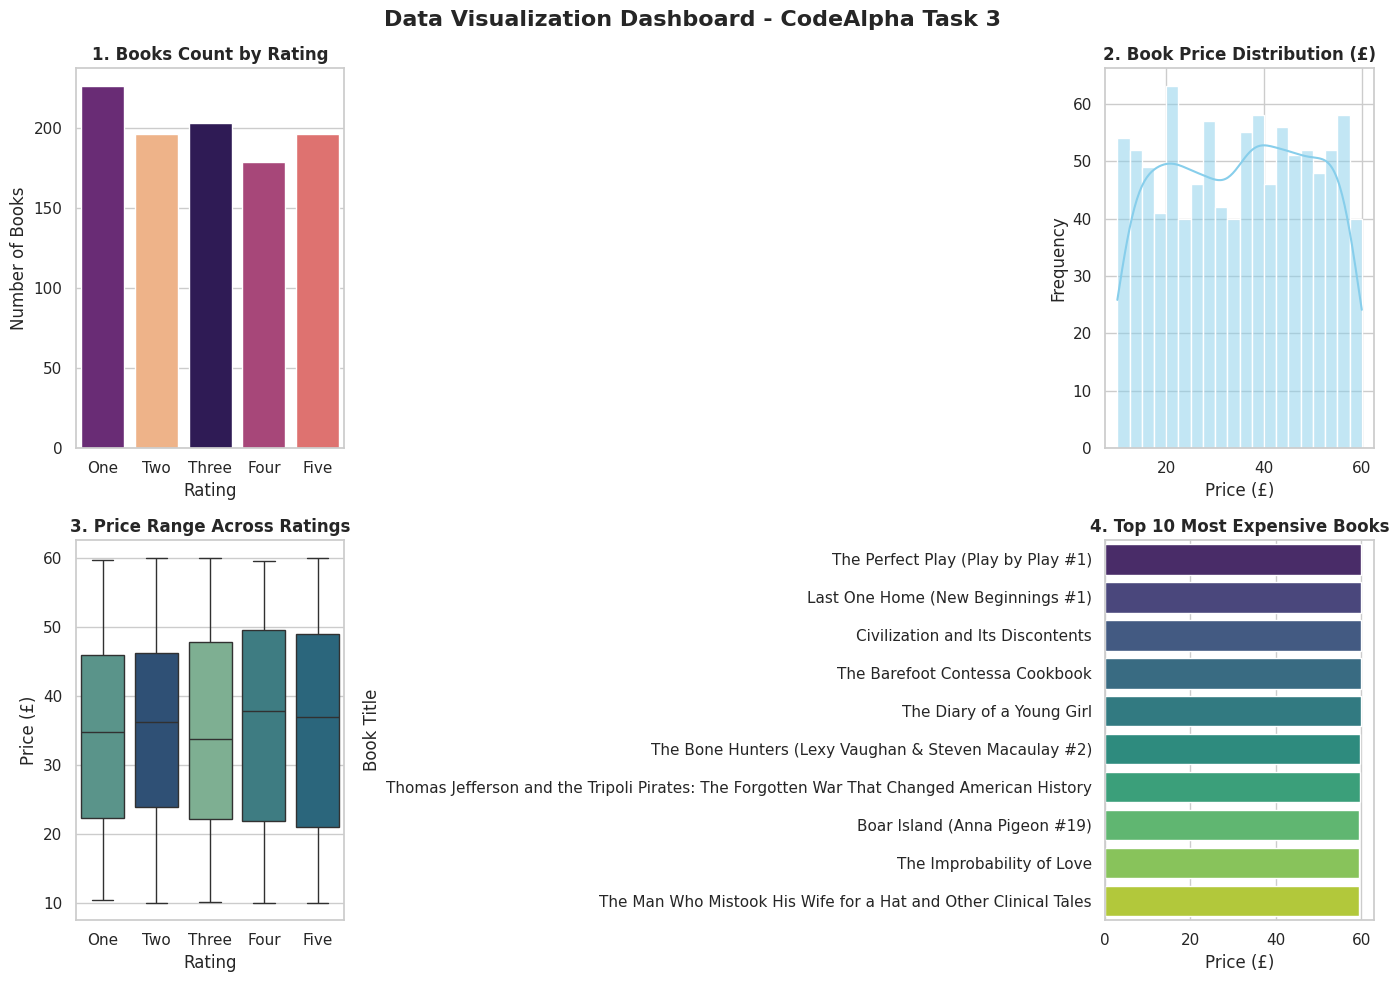

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("scraped_books_with_rating.csv")


df["Price_Clean"] = df["Price"].str.extract(r"(\d+\.\d+)").astype(float)


rating_order = ["One", "Two", "Three", "Four", "Five"]


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Data Visualization Dashboard - CodeAlpha Task 3",
    fontsize=16,
    fontweight="bold",
)

sns.countplot(
    ax=axes[0, 0],
    data=df,
    x="Rating",
    order=rating_order,
    palette="magma",
    hue="Rating",
    legend=False,
)
axes[0, 0].set_title("1. Books Count by Rating", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Number of Books")


sns.histplot(
    ax=axes[0, 1],
    data=df,
    x="Price_Clean",
    kde=True,
    color="skyblue",
    bins=20,
)
axes[0, 1].set_title(
    "2. Book Price Distribution (£)", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Price (£)")
axes[0, 1].set_ylabel("Frequency")


sns.boxplot(
    ax=axes[1, 0],
    data=df,
    x="Rating",
    y="Price_Clean",
    order=rating_order,
    palette="crest",
    hue="Rating",
    legend=False,
)
axes[1, 0].set_title(
    "3. Price Range Across Ratings", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Price (£)")


top10_expensive = df.nlargest(10, "Price_Clean")
sns.barplot(
    ax=axes[1, 1],
    data=top10_expensive,
    y="Book Title",
    x="Price_Clean",
    palette="viridis",
    hue="Book Title",
    legend=False,
)
axes[1, 1].set_title(
    "4. Top 10 Most Expensive Books", fontsize=12, fontweight="bold"
)
axes[1, 1].set_xlabel("Price (£)")
axes[1, 1].set_ylabel("Book Title")


plt.tight_layout()
plt.savefig("dashboard_summary.png", dpi=300)
plt.show()